#Importando as Bibliotecas

In [1]:
# Libraries
import sys
import scipy
import numpy
import matplotlib
import pandas
import sklearn

In [33]:
# Load libraries
import seaborn as sns
import pandas as pd
from pandas.plotting import scatter_matrix
import matplotlib.pyplot as plt
from sklearn import model_selection
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC

#Importando os dados pelo URL

In [5]:
# load through url
url = 'http://archive.ics.uci.edu/ml/machine-learning-databases/iris/iris.data'

attributes = ["sepal_length", "sepal_width", "petal_length", "petal_width", "class"]

dataset = pd.read_csv(url, names = attributes)

dataset.columns = attributes

#Análise Inicial dos Dados

In [16]:
print(dataset.shape)
print("\n")
print(dataset.head(20))

(150, 5)


    sepal_length  sepal_width  petal_length  petal_width        class
0            5.1          3.5           1.4          0.2  Iris-setosa
1            4.9          3.0           1.4          0.2  Iris-setosa
2            4.7          3.2           1.3          0.2  Iris-setosa
3            4.6          3.1           1.5          0.2  Iris-setosa
4            5.0          3.6           1.4          0.2  Iris-setosa
5            5.4          3.9           1.7          0.4  Iris-setosa
6            4.6          3.4           1.4          0.3  Iris-setosa
7            5.0          3.4           1.5          0.2  Iris-setosa
8            4.4          2.9           1.4          0.2  Iris-setosa
9            4.9          3.1           1.5          0.1  Iris-setosa
10           5.4          3.7           1.5          0.2  Iris-setosa
11           4.8          3.4           1.6          0.2  Iris-setosa
12           4.8          3.0           1.4          0.1  Iris-setosa
13       

In [17]:
# Um resumo de cada feature
print(dataset.describe())

       sepal_length  sepal_width  petal_length  petal_width
count    150.000000   150.000000    150.000000   150.000000
mean       5.843333     3.054000      3.758667     1.198667
std        0.828066     0.433594      1.764420     0.763161
min        4.300000     2.000000      1.000000     0.100000
25%        5.100000     2.800000      1.600000     0.300000
50%        5.800000     3.000000      4.350000     1.300000
75%        6.400000     3.300000      5.100000     1.800000
max        7.900000     4.400000      6.900000     2.500000


In [19]:
# Analisando a distribuição de classes
print(dataset.groupby("class").size())

# Como são 50 de cada classe, o dataset está bem balanceado e não será necessário um balanceamento.

class
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
dtype: int64


#Visualização dos Dados

##Gráficos Univariados

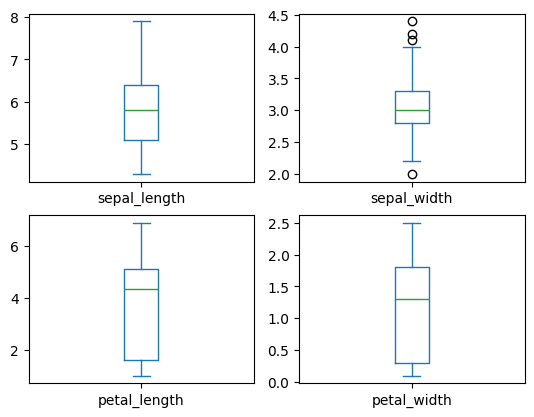

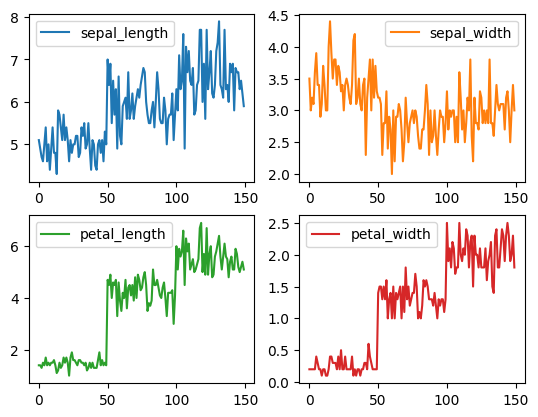

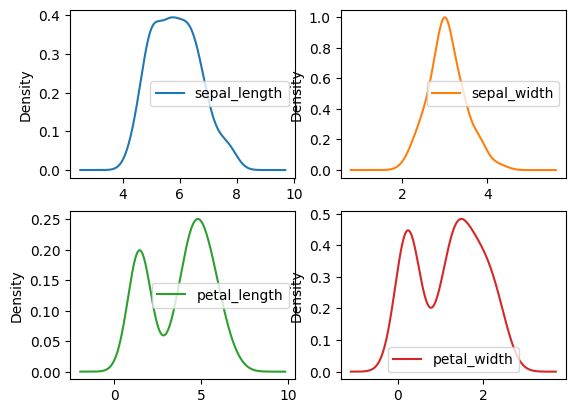

In [24]:
# Gráficos de caixas "bigode"
# Esses gráficos auxiliam na noção de distribuição dos dados no dataset
dataset.plot(kind="box", subplots=True, layout=(2,2), sharex=False, sharey=False)
plt.show()

dataset.plot(kind="line", subplots=True, layout=(2,2), sharex=False, sharey=False)
plt.show()

dataset.plot(kind="density", subplots=True, layout=(2,2), sharex=False, sharey=False)
plt.show()

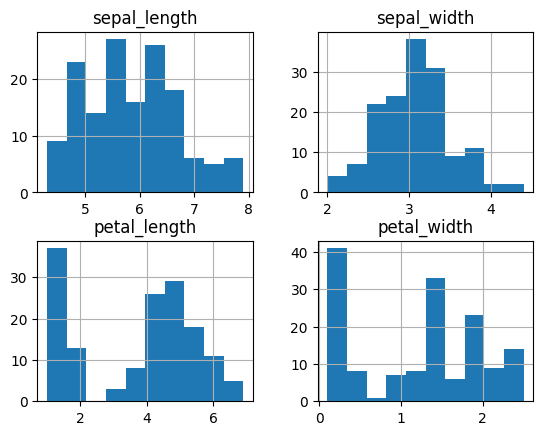

In [21]:
# Histogramas
dataset.hist()
plt.show()

##Gráficos Multivariados

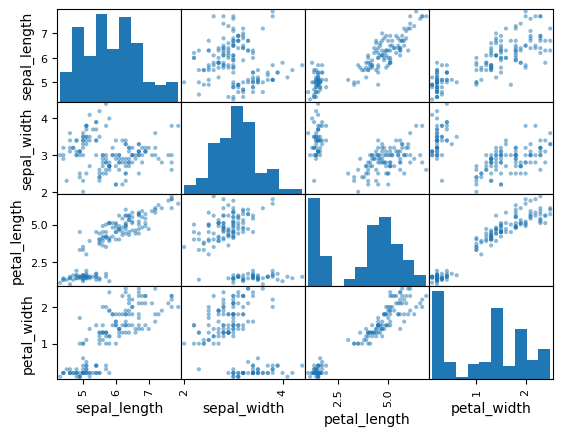

In [26]:
# Matriz de gráficos de dispersão
scatter_matrix(dataset)
plt.show()

In [31]:
# Calcula a matriz de correlação (por padrão usa o método de Pearson)
matriz_corr = dataset.corr(numeric_only=True)
print(matriz_corr)

              sepal_length  sepal_width  petal_length  petal_width
sepal_length      1.000000    -0.109369      0.871754     0.817954
sepal_width      -0.109369     1.000000     -0.420516    -0.356544
petal_length      0.871754    -0.420516      1.000000     0.962757
petal_width       0.817954    -0.356544      0.962757     1.000000


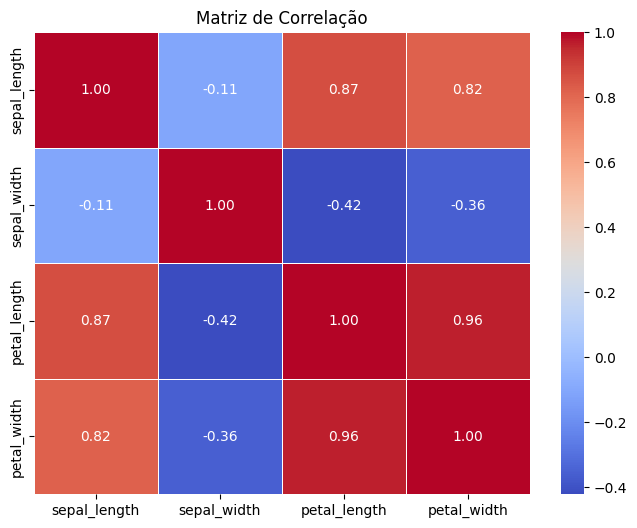

In [35]:

# Cria a figura
plt.figure(figsize=(8, 6))

# Plota o mapa de calor da correlação
sns.heatmap(dataset.corr(numeric_only=True), annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)

plt.title("Matriz de Correlação")
plt.show()

#Separando Datasets

In [36]:
# 1. Separar características (X) e o alvo/classe (Y)
array = dataset.values
X = array[:, 0:4]
Y = array[:, 4]

# 2. Criar o conjunto de Validação Final (Hold-out de 20%)
seed = 7
validation_size = 0.20
X_train, X_validation, Y_train, Y_validation = model_selection.train_test_split(
    X, Y, test_size=validation_size, random_state=seed
)

#Treinando Algoritmos
###Foram feitos testes com diversos modelos para descobrir o mais eficiente
- Regressão Logística (LR)
- Análise Linear Discriminante (LDA)
- K-vizinhos mais próximos (KNN).
- Árvores de Classificação (Decision Tree) e Regressão (CART).
- Gaussian Naive Bayes (NB).
- Support Vector Machines (SVM).

In [46]:
# Algoritmos a serem utilizados
models = []
models.append(("LR", LogisticRegression(max_iter=200)))
models.append(("LDA", LinearDiscriminantAnalysis()))
models.append(("KNN", KNeighborsClassifier()))
models.append(("CART", DecisionTreeClassifier()))
models.append(("NB", GaussianNB()))
models.append(("SVM", SVC(gamma="auto")))

# Avaliando cada modelo por turno (Com base na acurácia)
scoring = ['accuracy']

results_acc = []
names = []

for name, model in models:
   kfold = model_selection.StratifiedKFold(n_splits=10, random_state=seed, shuffle=True)
   cv_results = model_selection.cross_validate(model, X_train, Y_train, cv=kfold, scoring=scoring)

   # Extraindo as listas de resultados das 10 fatias
   acc = cv_results['test_accuracy']

   results_acc.append(acc)
   names.append(name)

   # Imprimindo a média e o desvio padrão de ambas as métricas
   msg = f"{name: <4} | Acurácia: {acc.mean():.4f} (+/- {acc.std():.4f})"
   print(msg)

LR   | Acurácia: 0.9917 (+/- 0.0250)
LDA  | Acurácia: 0.9750 (+/- 0.0382)
KNN  | Acurácia: 0.9833 (+/- 0.0333)
CART | Acurácia: 0.9833 (+/- 0.0333)
NB   | Acurácia: 0.9750 (+/- 0.0382)
SVM  | Acurácia: 0.9917 (+/- 0.0250)


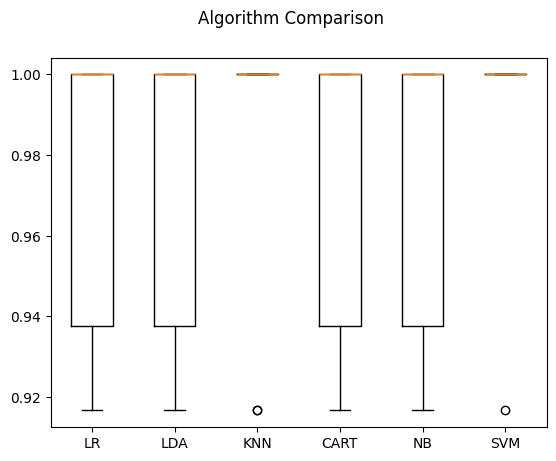

In [47]:
# Comparando algoritmos
fig = plt.figure()
fig.suptitle("Algorithm Comparison")
ax = fig.add_subplot(111)
plt.boxplot(results)
ax.set_xticklabels(names)
plt.show()

#Realizando previsão -- Teste

In [50]:
# O loop vai pegar um modelo por vez da lista
for name, model in models:
    # Treina o modelo com os dados de treino
    model.fit(X_train, Y_train)

    # Faz as previsões usando os dados de validação que estavam guardados
    predictions = model.predict(X_validation)

    # Imprime os resultados de forma organizada
    print(f"=========================================")
    print(f"MODELO: {name}")
    print(f"=========================================")
    print(f"Acurácia: {accuracy_score(Y_validation, predictions):.4f}\n")

    print("Matriz de Confusão:")
    print(confusion_matrix(Y_validation, predictions))
    print("\nRelatório de Classificação:")
    print(classification_report(Y_validation, predictions))
    print("\n")

MODELO: LR
Acurácia: 0.8667

Matriz de Confusão:
[[ 7  0  0]
 [ 0 10  2]
 [ 0  2  9]]

Relatório de Classificação:
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00         7
Iris-versicolor       0.83      0.83      0.83        12
 Iris-virginica       0.82      0.82      0.82        11

       accuracy                           0.87        30
      macro avg       0.88      0.88      0.88        30
   weighted avg       0.87      0.87      0.87        30



MODELO: LDA
Acurácia: 0.9667

Matriz de Confusão:
[[ 7  0  0]
 [ 0 11  1]
 [ 0  0 11]]

Relatório de Classificação:
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00         7
Iris-versicolor       1.00      0.92      0.96        12
 Iris-virginica       0.92      1.00      0.96        11

       accuracy                           0.97        30
      macro avg       0.97      0.97      0.97        30
   weighted avg      

In [54]:
# Instancia o modelo campeão definitivo
modelo_final = LinearDiscriminantAnalysis()

# Treina com TODO o dataset (usando as variáveis X e Y lá do início)
modelo_final.fit(X, Y)

LinearDiscriminantAnalysis()

In [55]:
import joblib

# Salva o modelo no seu disco rígido
joblib.dump(modelo_final, 'modelo_lda_iris.pkl')
print("Modelo salvo com sucesso!")

Modelo salvo com sucesso!


#Testando modelo com dados novos

In [58]:
import joblib

# Carrega o modelo treinado
modelo_carregado = joblib.load('modelo_lda_iris.pkl')

# Simulando uma flor encontrada no jardim (Comprimento/Largura da Sépala e Pétala)
flor_inedita = [[5.7, 3.0, 1.2, 0.2]]

previsao = modelo_carregado.predict(flor_inedita)
print(f"A espécie detectada é: {previsao[0]}")

A espécie detectada é: Iris-setosa
